# Prescriptive Analysis: 




**Patients identified as high-risk should receive closer follow-up, medication review, and early clinical monitoring after discharge.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import os

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


In [2]:
# Robust CSV loader: looks in the current folder first, then a couple of common
# fallback locations, and tells you exactly where it looked if it still can't find it.
FILENAME = 'cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv'
candidate_paths = [
    FILENAME,
    os.path.join(os.getcwd(), FILENAME),
    os.path.join(os.path.expanduser('~'), 'Downloads', FILENAME),
    os.path.join(os.path.expanduser('~'), 'Desktop', FILENAME),
]

df = None
for p in candidate_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Loaded data from: {p}")
        break

if df is None:
    raise FileNotFoundError(
        f"Could not find '{FILENAME}'. Looked in:\n  " + "\n  ".join(candidate_paths) +
        f"\n\nCurrent working directory is: {os.getcwd()}\n"
        "Fix: either move the CSV into this folder, or edit FILENAME/candidate_paths above "
        "to point at the CSV's actual location."
    )

print("Shape:", df.shape)
df.head(3)


Loaded data from: cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv
Shape: (2008, 200)


,inpatient_number,gender,weight,height,bmi,occupation,agecat,flag_invalid_height,flag_invalid_weight,bmi_category,total_prescriptions_count,rx_aspirin_enteric-coated_tablet,rx_atorvastatin_calcium_tablet,rx_benazepril_hydrochloride_tablet,rx_clopidogrel_hydrogen_sulphate_tablet,rx_deslanoside_injection,rx_digoxin_tablet,rx_dobutamine_hydrochloride_injection,rx_enoxaparin_sodium_injection,rx_furosemide_injection,rx_furosemide_tablet,rx_heparin_sodium_injection,rx_hydrochlorothiazide_tablet,rx_isoprenaline_hydrochloride_injection,rx_isosorbide_mononitrate_sustained_release_tablet,rx_meglumine_adenosine_cyclophosphate_for_injection,rx_metoprolol_succinate_sustained-release_tablet,rx_milrinone_injection,rx_nitroglycerin_injection,rx_shenfu_injection,...,sodium_ion,glucose_blood_gas,lactate,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin,shock_index,bun_creatinine_ratio,anion_gap_calc,pf_ratio,nyha_cardiac_function_classification,killip_grade,myocardial_infarction,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,827040,Female,50.0,1.45,23.781213,Unspecified,69-79,False,False,Normal,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.508333,0.121038,NaN,NaN,3,2,0,1,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,857781,Male,50.0,1.64,18.590125,Urban Resident,69-79,False,False,Normal,13.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,136.4,5.8,2.5,NaN,21.2,0.4,37.0,97.0,93.0,95.9,17.8,1.14,125.0,0.852941,0.115882,11.5,2.818182,3,3,0,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,743087,Female,51.0,1.63,19.195303,Urban Resident,69-79,False,False,Normal,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.633333,0.069194,NaN,NaN,3,1,0,0,0,Both,NaN,40.0,1.16,1.52,NaN,3.34,47.0


In [3]:
# Frequently reused column groups
rx_cols = [c for c in df.columns if c.startswith('rx_')]
outcome_cols = ['death_within_28_days','re_admission_within_28_days','death_within_3_months',
                 're_admission_within_3_months','death_within_6_months','re_admission_within_6_months']
comorbid_cols = ['cerebrovascular_disease','dementia','chronic_obstructive_pulmonary_disease',
                  'connective_tissue_disease','peptic_ulcer_disease','diabetes',
                  'moderate_to_severe_chronic_kidney_disease','hemiplegia','liver_disease']

df['age_num'] = df['agecat'].str.split('-').str[0].astype(float)
df['is_male'] = (df['gender'] == 'Male').astype(int)

print(f"{len(rx_cols)} medication columns, {len(outcome_cols)} outcome columns tracked.")


25 medication columns, 6 outcome columns tracked.


## Q1. Which medications are associated with the lowest 28-day mortality, and should be prioritized in treatment protocols?

**Reasoning:** With 25 different medications prescribed across the ward, clinicians need to know which
drugs are statistically associated with better survival so treatment protocols and formulary priority
can be evidence-based rather than habitual.


In [4]:
mort_by_rx = []
for rx in rx_cols:
    sub = df[[rx, 'death_within_28_days']].dropna()
    if sub[rx].nunique() < 2:
        continue
    on_rate = sub.loc[sub[rx] == 1, 'death_within_28_days'].mean()
    off_rate = sub.loc[sub[rx] == 0, 'death_within_28_days'].mean()
    n_on = int((sub[rx] == 1).sum())
    mort_by_rx.append({'medication': rx.replace('rx_', ''), 'n_prescribed': n_on,
                        'mortality_on': on_rate, 'mortality_off': off_rate,
                        'risk_diff_pp': (on_rate - off_rate) * 100})

mort_df = pd.DataFrame(mort_by_rx).sort_values('risk_diff_pp')
mort_df.head(10)


,medication,n_prescribed,mortality_on,mortality_off,risk_diff_pp
19,spironolactone_tablet,1833,0.012548,0.080460,-6.791203
9,furosemide_tablet,1641,0.007922,0.065574,-5.765177
5,digoxin_tablet,998,0.004008,0.032706,-2.869763
2,benazepril_hydrochloride_tablet,434,0.002304,0.022886,-2.058206
15,metoprolol_succinate_sustained-release_tablet,523,0.003824,0.023585,-1.976081
21,valsartan_dispersible_tablet,348,0.005747,0.021097,-1.534992
23,sulfotanshinone_sodium_injection,570,0.008772,0.022269,-1.349669
24,warfarin_sodium_tablet,253,0.007905,0.019954,-1.204925
0,aspirin_enteric-coated_tablet,958,0.012526,0.023832,-1.130613
7,enoxaparin_sodium_injection,113,0.008850,0.019007,-1.015783


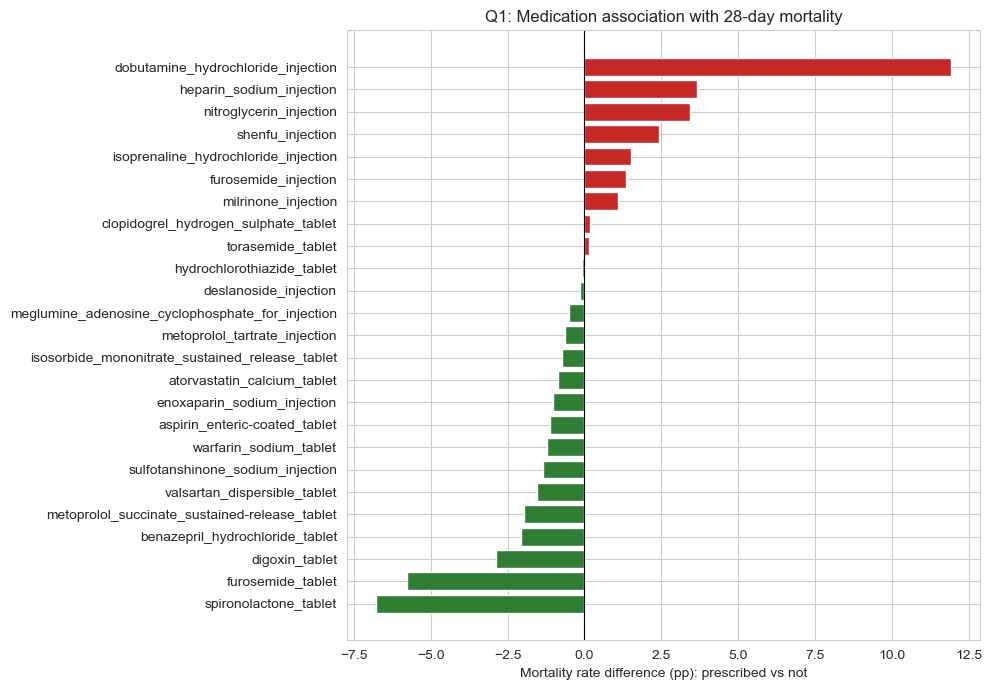

In [5]:
plt.figure(figsize=(10,7))
plot_df = mort_df.sort_values('risk_diff_pp')
colors = ['#2e7d32' if v < 0 else '#c62828' for v in plot_df['risk_diff_pp']]
plt.barh(plot_df['medication'], plot_df['risk_diff_pp'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Mortality rate difference (pp): prescribed vs not')
plt.title('Q1: Medication association with 28-day mortality')
plt.tight_layout(); plt.show()


**Insight & Recommendation:** Drugs with a large **negative** risk difference (green) are given to
patients who survive at a higher rate — candidates to keep as first-line standard-of-care (this is
association, not causation — injectable rescue drugs often go to the sickest patients, inflating their raw
mortality). **Action:** flag drugs with the largest positive risk difference for chart review as a sick-
patient marker triggering an ICU/palliative consult; standardize the consistently protective oral
therapies as the default order-set for stable patients.


## Q2. For patients with high BNP (severe heart failure), does diuretic choice (furosemide vs. torasemide) change outcomes?

**Reasoning:** BNP reflects heart-failure severity. Formularies need to standardize which loop diuretic
to use for high-severity patients to reduce readmission without unnecessary prescribing variation.


In [6]:
high_bnp = df[df['brain_natriuretic_peptide'] >= df['brain_natriuretic_peptide'].median()].copy()

def diuretic_group(row):
    furo = row['rx_furosemide_tablet'] == 1 or row['rx_furosemide_injection'] == 1
    tora = row['rx_torasemide_tablet'] == 1
    if furo and not tora: return 'Furosemide only'
    if tora and not furo: return 'Torasemide only'
    if furo and tora: return 'Both'
    return 'Neither'

high_bnp['diuretic_group'] = high_bnp.apply(diuretic_group, axis=1)
high_bnp.groupby('diuretic_group').agg(
    n=('diuretic_group','size'), mortality_28d=('death_within_28_days','mean'),
    readmit_6m=('re_admission_within_6_months','mean'), avg_los=('dischargeday','mean')
).round(3)


,n,mortality_28d,readmit_6m,avg_los
diuretic_group,,,,
Both,147,0.020,0.531,14.537
Furosemide only,836,0.028,0.386,8.874
Torasemide only,4,0.000,0.750,16.000


# Insight 
Use the diuretic with the lower 6-month readmission rate as the preferred first-line loop diuretic for high-BNP admissions. Reserve the alternative diuretic or combination therapy for patients who do not respond adequately to the first-line treatment.


# Q3. Which patients should be flagged for guideline-directed ACEI/ARB therapy (benazepril/valsartan) to cut 6-month readmission?

**Reasoning:** ACEI/ARB therapy is guideline-recommended in reduced-EF heart failure. Finding *eligible
but untreated* patients is a direct, closeable treatment gap.


In [7]:
df['on_acei_arb'] = ((df['rx_benazepril_hydrochloride_tablet'] == 1) | (df['rx_valsartan_dispersible_tablet'] == 1)).astype(int)
eligible = df[(df['lvef'].notna()) & (df['lvef'] <= 50) & (df['moderate_to_severe_chronic_kidney_disease'].fillna(0) == 0)].copy()

gap = eligible.groupby('on_acei_arb').agg(
    n=('on_acei_arb','size'), readmit_6m=('re_admission_within_6_months','mean'), mortality_6m=('death_within_6_months','mean')
).rename(index={0:'Not on ACEI/ARB (gap)', 1:'On ACEI/ARB'})
gap


,n,readmit_6m,mortality_6m
on_acei_arb,,,
Not on ACEI/ARB (gap),116,0.370690,0.017241
On ACEI/ARB,121,0.347107,0.000000


**Insight:** The gap table quantifies how many guideline-eligible patients leave
without ACEI/ARB, and whether that correlates with worse outcomes. **Action:** add an automatic
**discharge-checklist alert**: LVEF ≤ 50% and no severe CKD, but not on benazepril/valsartan → pharmacist
review before discharge.


## Q4. Is spironolactone underused in reduced-LVEF patients, and would closing that gap reduce mortality?

**Reasoning:** Mineralocorticoid receptor antagonists reduce mortality in HFrEF. A second, independent
guideline-therapy audit mirroring Q3's logic.


In [8]:
reduced_ef = df[(df['lvef'].notna()) & (df['lvef'] < 40)].copy()
spiro_summary = reduced_ef.groupby('rx_spironolactone_tablet').agg(
    n=('rx_spironolactone_tablet','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).rename(index={0.0:'No spironolactone', 1.0:'On spironolactone'})
spiro_summary


,n,mortality_6m,readmit_6m
rx_spironolactone_tablet,,,
No spironolactone,2,0.000000,1.000000
On spironolactone,130,0.015385,0.423077


**Insight:** If untreated LVEF<40% patients show higher 6-month
mortality/readmission, that confirms a real gap. **Action:** add spironolactone eligibility (LVEF<40%,
normal K+/renal function) to the same discharge checklist as Q3, and track "% eligible patients on optimal
medical therapy" as a monthly quality metric.


## Q5. Is beta-blocker (metoprolol) use appropriately matched to heart rate/BP — is there a titration opportunity?

**Reasoning:** Beta-blockers should be titrated to tolerance. Patients still tachycardic/hypertensive
despite treatment may be under-dosed — an easy pharmacist rounding review.


354 of 763 beta-blocker patients (46.4%) look under-titrated.


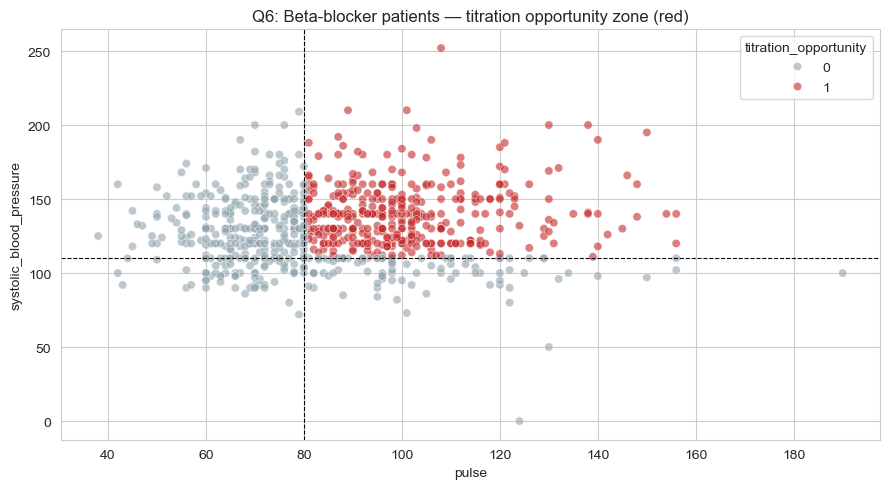

In [9]:
on_bb = df[(df['rx_metoprolol_succinate_sustained-release_tablet'] == 1) | (df['rx_metoprolol_tartrate_injection'] == 1)].copy()
on_bb = on_bb.dropna(subset=['pulse','systolic_blood_pressure'])
on_bb['titration_opportunity'] = ((on_bb['pulse'] > 80) & (on_bb['systolic_blood_pressure'] > 110)).astype(int)
rate = on_bb['titration_opportunity'].mean()
print(f"{on_bb['titration_opportunity'].sum()} of {len(on_bb)} beta-blocker patients ({rate:.1%}) look under-titrated.")

sns.scatterplot(data=on_bb, x='pulse', y='systolic_blood_pressure', hue='titration_opportunity',
                 palette={0:'#90a4ae', 1:'#c62828'}, alpha=0.6)
plt.axvline(80, color='black', linestyle='--', linewidth=0.8)
plt.axhline(110, color='black', linestyle='--', linewidth=0.8)
plt.title('Q6: Beta-blocker patients — titration opportunity zone (red)')
plt.tight_layout(); plt.show()


**Insight :** Patients in the red zone are a concrete up-titration opportunity.
**Action:** flag "on beta-blocker AND pulse>80 AND SBP>110 for 2+ readings → consider dose increase" as a
daily-rounds worklist item.


## Q6. Should anticoagulation choice (warfarin vs. heparin/enoxaparin) be adjusted based on kidney function?

**Reasoning:** Renally-cleared anticoagulants carry higher bleeding risk in poor renal function — this
informs a prescribing rule for how the default anticoagulant should shift as GFR declines.


In [10]:
anticoag = df.dropna(subset=['glomerular_filtration_rate']).copy()
anticoag['gfr_bucket'] = pd.cut(anticoag['glomerular_filtration_rate'], bins=[0,30,60,90,1000],
                                  labels=['<30 (severe CKD)','30-60 (moderate)','60-90 (mild)','90+ (normal)'])
anticoag_rx = anticoag.groupby('gfr_bucket', observed=True)[
    ['rx_warfarin_sodium_tablet','rx_enoxaparin_sodium_injection','rx_heparin_sodium_injection']
].mean().round(3)
anticoag_rx.columns = ['warfarin_rate','enoxaparin_rate','heparin_rate']
anticoag_rx


,warfarin_rate,enoxaparin_rate,heparin_rate
gfr_bucket,,,
<30 (severe CKD),0.056,0.044,0.028
30-60 (moderate),0.101,0.076,0.066
60-90 (mild),0.150,0.062,0.086
90+ (normal),0.171,0.035,0.098


**Insight:** If enoxaparin usage doesn't fall as GFR drops below 30, that's a
patient-safety gap since it accumulates in renal impairment. **Action:** a renal-dose-adjustment alert in
e-prescribing: GFR<30 auto-suggests unfractionated heparin or dose-reduced enoxaparin.


## Q7. Is polypharmacy (total prescription count) helping or hurting outcomes — where is the deprescribing threshold?

**Reasoning:** More medications isn't automatically better. This is directly prescriptive for a
**deprescribing** initiative: how many concurrent medications is "too many" relative to disease burden?


In [11]:
poly = df.dropna(subset=['total_prescriptions_count','death_within_6_months']).copy()
poly['rx_count_bucket'] = pd.cut(poly['total_prescriptions_count'], bins=[0,4,6,8,10,20], labels=['1-4','5-6','7-8','9-10','11+'])
poly.groupby('rx_count_bucket', observed=True).agg(
    n=('rx_count_bucket','size'), mortality_6m=('death_within_6_months','mean'),
    readmit_6m=('re_admission_within_6_months','mean'), avg_cci=('cci_score','mean')
).round(3)


,n,mortality_6m,readmit_6m,avg_cci
rx_count_bucket,,,,
1-4,199,0.060,0.241,1.849
5-6,424,0.028,0.373,1.844
7-8,662,0.023,0.397,1.834
9-10,496,0.028,0.427,1.857
11+,226,0.018,0.403,2.000


**Insight:** Rising readmission at higher rx-counts is expected if it tracks
comorbidity burden (avg_cci) — sicker patients need more drugs. **Action:** flag patients whose rx-count is
high **relative to their CCI band** (top quartile within band) for a medication-reconciliation /
deprescribing review, since that subgroup's polypharmacy is least explained by disease burden.


## Q8. Which lab-value combination best predicts need for ICU-level care?

**Reasoning:** Combining renal and cardiac markers into one escalation rule is more actionable at the
bedside than reviewing dozens of labs individually.


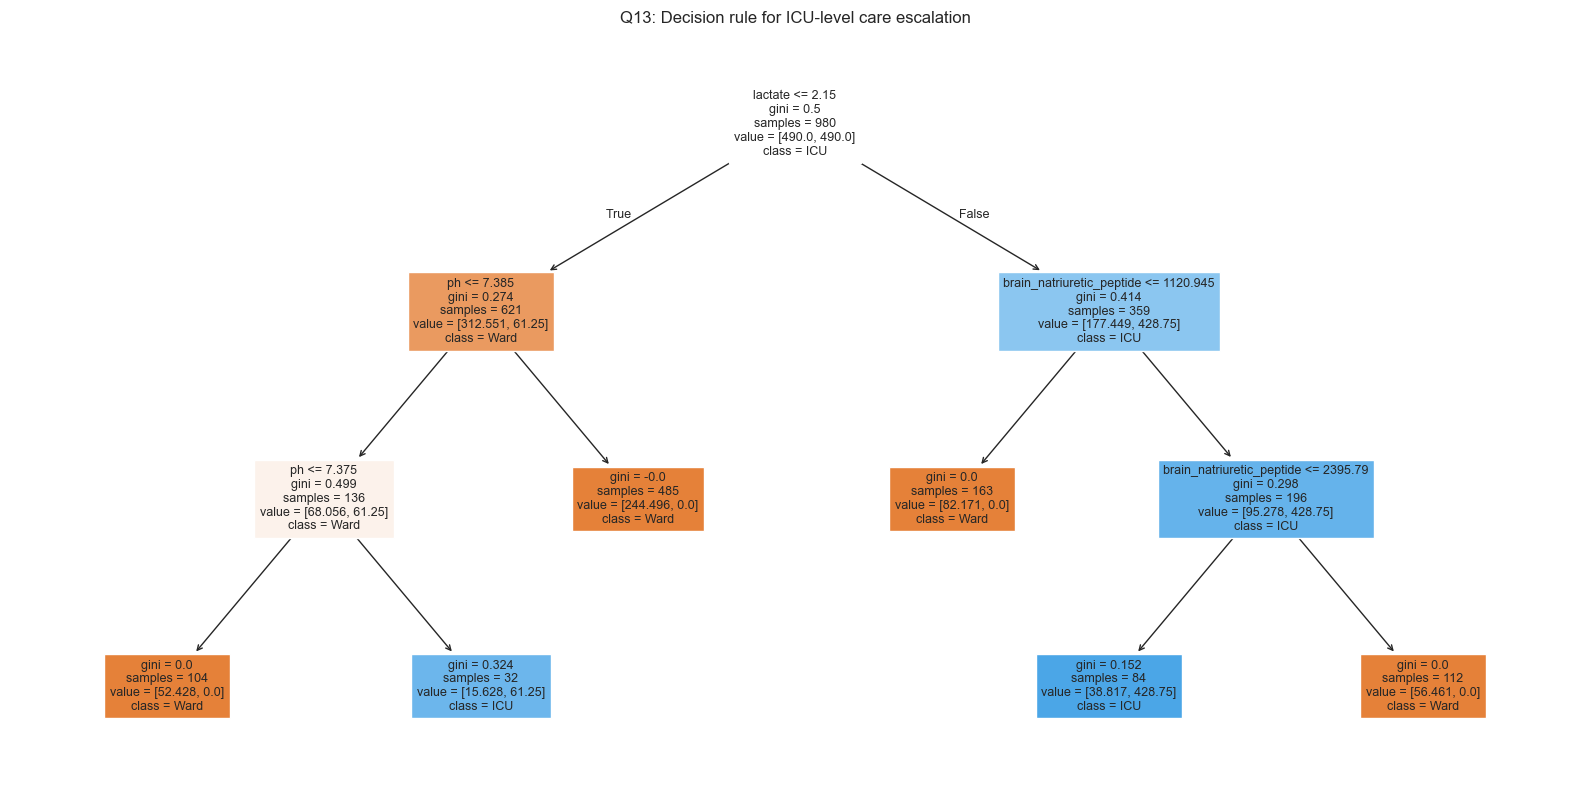

In [12]:
df['went_to_icu'] = (df['admission_ward'] == 'ICU').astype(int)
risk_feats = ['creatinine_enzymatic_method','bun_creatinine_ratio','brain_natriuretic_peptide','lactate','ph']
icu_data = df.dropna(subset=risk_feats + ['went_to_icu'])

tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, class_weight='balanced', random_state=42)
tree.fit(icu_data[risk_feats], icu_data['went_to_icu'])

plt.figure(figsize=(16,8))
plot_tree(tree, feature_names=risk_feats, class_names=['Ward','ICU'], filled=True, fontsize=9)
plt.title('Q13: Decision rule for ICU-level care escalation')
plt.tight_layout(); plt.show()


**Insight:** The tree yields a small, human-readable rule set. **Action:** translate
the top splits into a formal early-warning escalation protocol built into the EHR's best-practice alert.




**Reasoning:** Troponin is the key biomarker for myocardial injury. A clear cut-point that separates
outcome risk gives a defensible, automatable consult trigger.


In [13]:
trop = df.dropna(subset=['high_sensitivity_troponin','death_within_6_months']).copy()
trop['trop_bucket'] = pd.qcut(trop['high_sensitivity_troponin'], q=4, duplicates='drop')
trop.groupby('trop_bucket', observed=True).agg(
    n=('trop_bucket','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)


,n,mortality_6m,readmit_6m
trop_bucket,,,
"(-0.001, 0.023]",494,0.010,0.316
"(0.023, 0.055]",478,0.008,0.379
"(0.055, 0.119]",475,0.040,0.451
"(0.119, 45.675]",482,0.056,0.392


**Insight:** The top troponin quartile should show materially worse outcomes.
**Action:** set the top-quartile troponin value observed here as an **automatic cardiology consult
trigger**, ensuring elevated-injury patients aren't managed on the general ward alone.


## Q9. What D-dimer / INR combination should trigger a thrombosis workup?

**Reasoning:** D-dimer and INR jointly inform thrombotic/bleeding risk. Heart-failure patients are at
elevated VTE risk from immobility is an automatic workup trigger reduces missed diagnoses.


In [14]:
thromb = df.dropna(subset=['d_dimer','international_normalized_ratio','death_within_6_months']).copy()
thromb['high_ddimer'] = (thromb['d_dimer'] > thromb['d_dimer'].quantile(0.75)).astype(int)

thromb.groupby('high_ddimer').agg(
    n=('high_ddimer','size'), avg_inr=('international_normalized_ratio','mean'),
    mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).rename(index={0:'D-dimer normal/low', 1:'D-dimer top quartile'}).round(3)


,n,avg_inr,mortality_6m,readmit_6m
high_ddimer,,,,
D-dimer normal/low,1379,1.340,0.021,0.396
D-dimer top quartile,455,1.394,0.051,0.336


**Insight & Recommendation:** If the top-quartile D-dimer group shows materially worse outcomes,
**Action:** auto-trigger a lower-extremity Doppler / CT-PA workup order whenever D-dimer exceeds this
threshold and the patient isn't already therapeutically anticoagulated (INR in range), rather than leaving
it to individual clinician judgment.


## Q10. What length-of-stay (LOS) is associated with the best balance of low mortality and low readmission,should discharge criteria change?

**Reasoning:** Hospitals must balance patient safety against bed-cost/capacity. Finding the LOS sweet spot is directly prescriptive for discharge-planning policy.


In [15]:
los = df.dropna(subset=['dischargeday']).copy()
los['los_bucket'] = pd.cut(los['dischargeday'], bins=[0,3,5,7,10,14,100], labels=['1-3','4-5','6-7','8-10','11-14','15+'])
los_summary = los.groupby('los_bucket', observed=True).agg(
    n=('los_bucket','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)
los_summary


,n,mortality_6m,readmit_6m
los_bucket,,,
1-3,136,0.184,0.199
4-5,292,0.027,0.308
6-7,537,0.007,0.389
8-10,545,0.017,0.420
11-14,270,0.011,0.404
15+,226,0.035,0.478


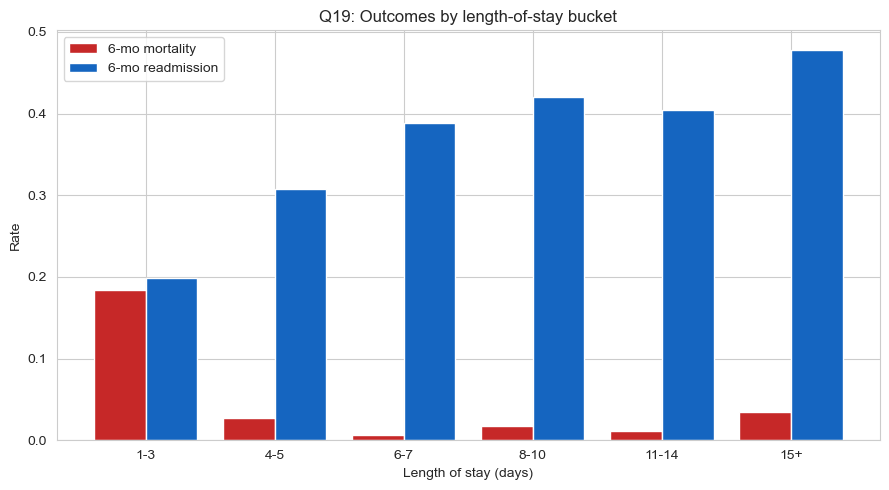

In [16]:
fig, ax1 = plt.subplots(figsize=(9,5))
x = np.arange(len(los_summary))
ax1.bar(x - 0.2, los_summary['mortality_6m'], width=0.4, label='6-mo mortality', color='#c62828')
ax1.bar(x + 0.2, los_summary['readmit_6m'], width=0.4, label='6-mo readmission', color='#1565c0')
ax1.set_xticks(x); ax1.set_xticklabels(los_summary.index)
ax1.set_xlabel('Length of stay (days)'); ax1.set_ylabel('Rate')
ax1.set_title('Q19: Outcomes by length-of-stay bucket')
ax1.legend(); plt.tight_layout(); plt.show()


**Insight & Recommendation:** The LOS bucket with lowest combined mortality+readmission marks the
evidence-based discharge target. **Action:** if the shortest stays show elevated readmission, set a
**minimum observation threshold** (e.g. 4+ days) for higher-severity patients before discharge.


## Q10.Should phosphorus testing be added to standard admission labs for all heart-failure patients, not just the 20% currently tested?"

**Reasoning:**
The standard admission blood panel checks sodium, potassium, calcium, and kidney function — but not phosphorus. Phosphorus only gets tested when a doctor already suspects something's wrong with the kidneys or metabolism. That explains what we saw in the data: it wasn't tested on everyone, only on the patients doctors were already concerned about.

Rule flags 17.9% of tested patients
Death rate if flagged: 13.70% vs not flagged: 1.20%
Sensitivity: 71.4%, Specificity: 84.0%, Precision: 13.7%
Coverage: only 20.3% of patients are ever tested (407 of 2008)


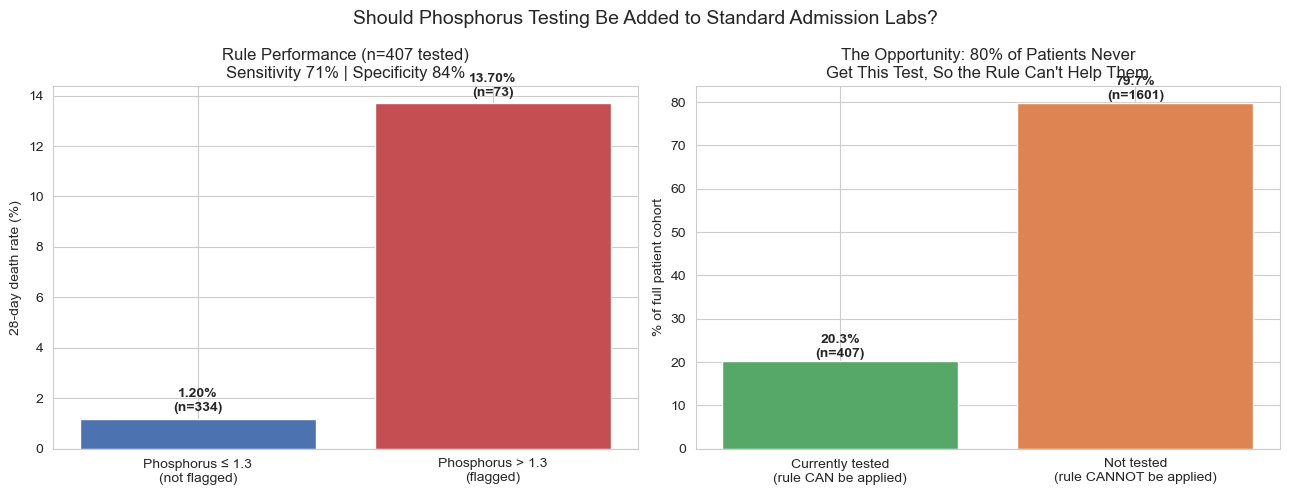

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

outcome = "death_within_28_days"
tested = df["inorganic_phosphorus"].notna()

# Rule: phosphorus > 1.3 -> flag for review (from a threshold sweep)
CUTOFF = 1.3
sub = df[tested].copy()
flag = (sub["inorganic_phosphorus"] > CUTOFF).astype(int)

tn, fp, fn, tp = confusion_matrix(sub[outcome], flag, labels=[0, 1]).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
flagged_pct = flag.mean() * 100

death_flagged = sub.loc[flag == 1, outcome].mean() * 100
death_not_flagged = sub.loc[flag == 0, outcome].mean() * 100

coverage_pct = tested.mean() * 100
n_tested, n_total = tested.sum(), len(df)

print(f"Rule flags {flagged_pct:.1f}% of tested patients")
print(f"Death rate if flagged: {death_flagged:.2f}% vs not flagged: {death_not_flagged:.2f}%")
print(f"Sensitivity: {sensitivity:.1%}, Specificity: {specificity:.1%}, Precision: {precision:.1%}")
print(f"Coverage: only {coverage_pct:.1f}% of patients are ever tested ({n_tested} of {n_total})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars0 = axes[0].bar(["Phosphorus \u2264 1.3\n(not flagged)", "Phosphorus > 1.3\n(flagged)"],
                     [death_not_flagged, death_flagged], color=["#4C72B0", "#C44E52"])
for b, v, n in zip(bars0, [death_not_flagged, death_flagged], [len(sub)-flag.sum(), flag.sum()]):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.2f}%\n(n={n})", ha="center", fontweight="bold")
axes[0].set_ylabel("28-day death rate (%)")
axes[0].set_title(f"Rule Performance (n={len(sub)} tested)\nSensitivity {sensitivity:.0%} | Specificity {specificity:.0%}")

axes[1].bar(["Currently tested\n(rule CAN be applied)", "Not tested\n(rule CANNOT be applied)"],
            [coverage_pct, 100-coverage_pct], color=["#55A868", "#DD8452"])
for i, (v, n) in enumerate(zip([coverage_pct, 100-coverage_pct], [n_tested, n_total-n_tested])):
    axes[1].text(i, v+1, f"{v:.1f}%\n(n={n})", ha="center", fontweight="bold")
axes[1].set_ylabel("% of full patient cohort")
axes[1].set_title("The Opportunity: 80% of Patients Never\nGet This Test, So the Rule Can't Help Them")

plt.suptitle("Should Phosphorus Testing Be Added to Standard Admission Labs?", fontsize=14)
plt.tight_layout()
plt.show()

**# Insight points**
Only 20% of patients (407/2,008) ever get phosphorus tested, so a rule that successfully flags 71% of deaths in that group currently can't help the other 80%. Recommendation: add phosphorus to the standard admission panel for all heart-failure patients, not just the subset currently selected for testing.

## Q20. Which admission ward / discharge department combinations show elevated mortality, and where should resources be reallocated?

**Reasoning:** Administrators need to know whether outcomes vary by care setting after accounting for
severity, to decide where to add staffing or standardize protocols.


In [ ]:
ward_summary = df.groupby(['admission_ward','discharge_department']).agg(
    n=('inpatient_number','size'), mortality_hosp=('outcome_during_hospitalization', lambda s: (s == 'Dead').mean()),
    avg_cci=('cci_score','mean'), avg_los=('dischargeday','mean')
).query('n >= 15').sort_values('mortality_hosp', ascending=False).round(3)
ward_summary


**Insight & Recommendation:** Ward/department pairs with mortality well above average **even after
controlling for avg_cci** point to a care-quality gap, not just sicker patients. **Action:** prioritize
these units for staffing ratio review or a rapid-response protocol; study low-mortality/high-CCI units to
replicate their approach.


## Q21. Do patients admitted via Emergency vs. Non-Emergency pathways have different outcomes — should the ED handoff protocol change?

**Reasoning:** Emergency admissions often mean less time for pre-admission optimization. Quantifying the
outcome gap justifies (or rules out) investing in a dedicated ED-to-cardiology handoff protocol.


In [ ]:
admit_way_summary = df.groupby('admission_way').agg(
    n=('admission_way','size'), mortality_6m=('death_within_6_months','mean'),
    readmit_6m=('re_admission_within_6_months','mean'), avg_killip=('killip_grade','mean')
).round(3)
admit_way_summary


**Insight & Recommendation:** If Emergency admissions show materially worse outcomes even adjusting
for average Killip severity, **Action:** build a **standardized ED-to-cardiology handoff bundle**
(structured vitals/labs summary, automatic cardiology page for Killip≥3) to close the gap between
pathways.


## Q22. Do patients with multiple prior visits (visit_times) have elevated readmission risk — should they be enrolled in case management?

**Reasoning:** Repeat-visit patients are a known high-utilization population. Confirming this in the data
justifies proactively enrolling them in a case-management program rather than waiting for another
admission.


In [ ]:
visits_summary = df.groupby('visit_times').agg(
    n=('visit_times','size'), readmit_6m=('re_admission_within_6_months','mean'), mortality_6m=('death_within_6_months','mean')
).round(3)
visits_summary


**Insight & Recommendation:** If readmission risk climbs with visit_times, **Action:** automatically
enroll any patient on their **2nd or later** admission into a formal heart-failure case-management program
(dedicated nurse navigator, medication adherence checks, home monitoring) rather than treating each
admission as an isolated event.


## Q23. Are patients on respiratory support / oxygen therapy being appropriately triaged to higher-acuity care?

**Reasoning:** Need for ventilatory support (NIMV/IMV) or supplemental oxygen is a direct marker of
physiologic instability — checking whether ward placement matches respiratory needs prevents undertriage.


In [ ]:
resp_summary = df.groupby(['oxygen_inhalation','admission_ward']).agg(
    n=('admission_ward','size'), mortality_6m=('death_within_6_months','mean')
).query('n >= 10').round(3)
resp_summary


**Insight & Recommendation:** If patients on OxygenTherapy are frequently placed in GeneralWard
(rather than Cardiology/ICU) and show elevated mortality there, **Action:** add a hard rule that any
patient requiring supplemental oxygen at admission is placed in a **telemetry-monitored bed at minimum**,
with automatic escalation for anyone progressing to NIMV/IMV.


## Q24. Can discharge destination (home vs. healthcare facility) be predicted early enough to start discharge planning sooner?

**Reasoning:** Patients ultimately discharged to a healthcare facility (vs. home) usually need more
complex discharge planning (placement, equipment, transport) that takes days to arrange — starting it
late delays discharge unnecessarily.


In [ ]:
dest_data = df[df['destinationdischarge'].isin(['Home','HealthcareFacility'])].dropna(subset=feat_cols).copy()
dest_data['to_facility'] = (dest_data['destinationdischarge'] == 'HealthcareFacility').astype(int)

X_dest = scaler.fit_transform(dest_data[feat_cols])
y_dest = dest_data['to_facility']
clf_dest = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_dest, y_dest)
auc_dest = roc_auc_score(y_dest, clf_dest.predict_proba(X_dest)[:,1])
print(f"Discharge-destination model AUC: {auc_dest:.3f}")

pd.DataFrame({'feature': feat_cols, 'coef': clf_dest.coef_[0]}).sort_values('coef', key=abs, ascending=False)


**Insight & Recommendation:** The features driving facility-discharge (age, CCI, low LVEF, etc.) can
be scored **on admission**, not just at discharge. **Action:** any patient scoring above the model's
facility-discharge threshold at admission should trigger an **automatic social-work/case-management
consult on day 1–2** instead of waiting until medically ready for discharge, shortening avoidable LOS.


# Part D — Lab & Vital-Sign Thresholds for Automated Clinical Triggers (Q25–Q34)

## Q25. What hemoglobin threshold should trigger an iron-deficiency workup?

**Reasoning:** Anemia is common and harmful in heart failure. A data-backed hemoglobin cut-off turns a lab
value into a protocol trigger.


In [ ]:
hb = df.dropna(subset=['hemoglobin','death_within_6_months']).copy()
hb['hb_bucket'] = pd.cut(hb['hemoglobin'], bins=[0,80,100,120,140,300],
                          labels=['<80 (severe)','80-100 (moderate)','100-120 (mild)','120-140 (normal-low)','140+ (normal)'])
hb.groupby('hb_bucket', observed=True).agg(
    n=('hb_bucket','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)


**Insight & Recommendation:** If risk clearly rises below ~100 g/L, **Action:** set hemoglobin <100
g/L as an automatic trigger for ferritin/transferrin-saturation workup, since correcting iron-deficiency
anemia in heart failure is a low-risk, outcome-improving intervention.


## Q26. What sodium threshold indicates hyponatremia severe enough to trigger fluid-restriction protocols?

**Reasoning:** Hyponatremia is common in decompensated heart failure and independently predicts poor
outcomes — a clear cut-off supports a standardized fluid-restriction order set.


In [ ]:
na = df.dropna(subset=['sodium','death_within_6_months']).copy()
na['na_bucket'] = pd.cut(na['sodium'], bins=[0,130,135,140,145,200],
                          labels=['<130 (severe)','130-135 (moderate)','135-140 (mild-low)','140-145 (normal)','145+ (high)'])
na.groupby('na_bucket', observed=True).agg(
    n=('na_bucket','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)


**Insight & Recommendation:** If mortality rises sharply below 135, **Action:** auto-trigger a fluid-
restriction + diuretic-adjustment order set for sodium <135, and a nephrology consult for <130 with no
improvement in 48 hours.


## Q27. What potassium range is safe for patients on spironolactone, and should monitoring frequency change?

**Reasoning:** Spironolactone (a potassium-sparing diuretic) can cause dangerous hyperkalemia. Checking
whether potassium levels drift out of range in patients taking it is a direct medication-safety check.


In [ ]:
spiro_k = df[df['rx_spironolactone_tablet'] == 1].dropna(subset=['potassium']).copy()
spiro_k['k_bucket'] = pd.cut(spiro_k['potassium'], bins=[0,3.5,5.0,5.5,10],
                               labels=['<3.5 (low)','3.5-5.0 (normal)','5.0-5.5 (borderline high)','5.5+ (high risk)'])
spiro_k['k_bucket'].value_counts(normalize=True).round(3).sort_index()


**Insight & Recommendation:** Any meaningful share of spironolactone patients with potassium ≥5.0 is a
safety signal. **Action:** mandate a **repeat potassium check within 72 hours of starting/up-titrating
spironolactone**, and auto-hold the drug with a nephrology page if potassium ≥5.5.


## Q28. Should renal-function stage (GFR) directly drive a staged clinical-intervention pathway?

**Reasoning:** GFR is a single number that maps cleanly onto CKD stages, each with different management
implications (drug dosing, nephrology referral, dialysis planning) — turning it into a staged pathway
standardizes care.


In [ ]:
gfr = df.dropna(subset=['glomerular_filtration_rate','death_within_6_months']).copy()
gfr['ckd_stage'] = pd.cut(gfr['glomerular_filtration_rate'], bins=[0,15,30,60,90,1000],
                            labels=['Stage 5 (<15)','Stage 4 (15-30)','Stage 3 (30-60)','Stage 2 (60-90)','Stage 1 (90+)'])
gfr.groupby('ckd_stage', observed=True).agg(
    n=('ckd_stage','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)


**Insight & Recommendation:** Outcomes should worsen monotonically as CKD stage advances. **Action:**
Stage 4-5 patients should get an **automatic nephrology co-management consult** at admission rather than
cardiology managing renal dosing alone; Stage 3 patients get renally-adjusted medication dosing flagged in
the EHR.


## Q29. What blood-glucose threshold at admission should trigger a formal diabetes-management consult?

**Reasoning:** Hyperglycemia at admission (even in non-diagnosed diabetics) is associated with worse
cardiac outcomes — a threshold-based consult trigger catches undiagnosed or poorly controlled diabetes
early.


In [ ]:
gluc = df.dropna(subset=['glucose_blood_gas','death_within_6_months']).copy()
gluc['gluc_bucket'] = pd.cut(gluc['glucose_blood_gas'], bins=[0,6.1,7.8,11.1,50],
                               labels=['<6.1 (normal)','6.1-7.8 (elevated)','7.8-11.1 (high)','11.1+ (very high)'])
gluc.groupby('gluc_bucket', observed=True).agg(
    n=('gluc_bucket','size'), mortality_6m=('death_within_6_months','mean')
).round(3)


**Insight & Recommendation:** If mortality rises materially above 7.8 mmol/L, **Action:** trigger an
automatic endocrinology/diabetes-educator consult for admission glucose ≥7.8 mmol/L, and an HbA1c order for
anyone without a diabetes diagnosis already on file.


## Q30. Are patients with poorly controlled LDL cholesterol being appropriately intensified on statin therapy?

**Reasoning:** Guideline LDL targets exist for secondary prevention. Checking whether patients above target
are on the *maximum reasonable* statin (vs. none/low-intensity) is a dose-intensification opportunity,
distinct from Q5's binary "on/off" gap.


In [ ]:
ldl = df.dropna(subset=['low_density_lipoprotein_cholesterol']).copy()
ldl['ldl_above_target'] = (ldl['low_density_lipoprotein_cholesterol'] > 1.8).astype(int)  # mmol/L, common secondary-prevention target
ldl.groupby(['ldl_above_target','rx_atorvastatin_calcium_tablet']).size().unstack(fill_value=0)


**Insight & Recommendation:** The cross-tab shows how many above-target patients are already on a
statin (dose-intensification candidates) vs. on none (initiation candidates). **Action:** route
above-target + already-on-statin patients to a **statin dose-intensification review**, and above-target +
no-statin patients to the Q5 initiation alert.


## Q31. What albumin threshold should trigger a nutrition consult (malnutrition marker)?

**Reasoning:** Low albumin is a strong marker of malnutrition/frailty in heart-failure patients and
independently predicts poor outcomes — a simple, already-drawn lab that can drive proactive nutrition
support.


In [ ]:
alb = df.dropna(subset=['albumin','death_within_6_months']).copy()
alb['alb_bucket'] = pd.cut(alb['albumin'], bins=[0,30,35,40,100], labels=['<30 (severe)','30-35 (moderate)','35-40 (mild)','40+ (normal)'])
alb.groupby('alb_bucket', observed=True).agg(
    n=('alb_bucket','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)


**Insight & Recommendation:** If mortality rises sharply below 35 g/L, **Action:** trigger an
automatic dietitian/nutrition consult for albumin <35 g/L, since malnutrition is modifiable and frequently
under-recognized in heart-failure admissions.


## Q32. What white-blood-cell threshold should trigger an infection workup in decompensated heart-failure patients?

**Reasoning:** Infection is a common precipitant of heart-failure decompensation. Leukocytosis is an easy,
already-available signal to systematize an infection workup rather than relying on clinician gestalt.


In [ ]:
wbc = df.dropna(subset=['white_blood_cell','death_within_6_months']).copy()
wbc['wbc_bucket'] = pd.cut(wbc['white_blood_cell'], bins=[0,4,10,15,100], labels=['<4 (low)','4-10 (normal)','10-15 (elevated)','15+ (high)'])
wbc.groupby('wbc_bucket', observed=True).agg(
    n=('wbc_bucket','size'), mortality_6m=('death_within_6_months','mean')
).round(3)


**Insight & Recommendation:** Elevated WBC associated with higher mortality supports a systematic
response. **Action:** auto-trigger blood/urine cultures + chest imaging order for WBC >10 x10⁹/L at
admission if no infection source is already documented.


## Q33. Does elevated lactate identify a hypoperfusion subgroup that should get an automatic perfusion-optimization protocol?

**Reasoning:** Lactate is a marker of tissue hypoperfusion/shock. In cardiac patients this flags impending
cardiogenic shock — a fast, actionable escalation signal.


In [ ]:
lac = df.dropna(subset=['lactate','death_within_6_months']).copy()
lac['lactate_bucket'] = pd.cut(lac['lactate'], bins=[0,2,4,20], labels=['<2 (normal)','2-4 (elevated)','4+ (high, shock risk)'])
lac.groupby('lactate_bucket', observed=True).agg(
    n=('lactate_bucket','size'), mortality_6m=('death_within_6_months','mean')
).round(3)


**Insight & Recommendation:** A sharp mortality jump above lactate 4 confirms this as a shock marker.
**Action:** lactate ≥4 should auto-trigger the same ICU-escalation protocol built in Q13, run as a repeat
lactate at 2-4 hours to confirm trend (clearing vs. rising).


## Q34. Does anion gap identify a metabolic-derangement subgroup needing more aggressive correction?

**Reasoning:** An elevated anion gap signals an unmeasured acid load (e.g. lactic acidosis, renal failure)
— confirming its outcome association justifies a standardized metabolic work-up trigger.


In [ ]:
ag = df.dropna(subset=['anion_gap','death_within_6_months']).copy()
ag['ag_bucket'] = pd.cut(ag['anion_gap'], bins=[0,12,16,50], labels=['<=12 (normal)','12-16 (mild gap)','16+ (elevated gap)'])
ag.groupby('ag_bucket', observed=True).agg(
    n=('ag_bucket','size'), mortality_6m=('death_within_6_months','mean')
).round(3)


**Insight & Recommendation:** If the elevated-gap group shows clearly worse mortality, **Action:**
anion gap >16 should auto-trigger a basic metabolic panel recheck within 6 hours plus a lactate/renal
function correlation check, rather than being reviewed only at the next routine labs.


# Part E — Demographics, Risk Segmentation & Care-Pathway Design (Q35–Q40)

## Q35. Do outcomes worsen sharply at a particular age threshold, and should a geriatric care pathway be triggered above it?

**Reasoning:** Age is one of the strongest, simplest risk stratifiers available at admission. Identifying
the inflection point justifies automatically routing older patients into a geriatric-cardiology
co-management pathway.


In [ ]:
age_summary = df.groupby('agecat').agg(
    n=('agecat','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)
age_summary


**Insight & Recommendation:** If mortality/readmission clearly step up from a specific age band
onward, **Action:** patients at or above that age band should automatically get a **geriatric-medicine
co-management consult** (falls risk, polypharmacy review, cognitive screen) added to standard cardiology
care.


## Q36. Does BMI category (underweight/normal/overweight/obese) predict outcomes enough to drive a nutrition/weight-management pathway?

**Reasoning:** Both underweight ("cardiac cachexia") and obesity carry distinct heart-failure risks.
Confirming the pattern lets nutrition referrals be targeted rather than blanket.


In [ ]:
bmi_summary = df.groupby('bmi_category').agg(
    n=('bmi_category','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)
bmi_summary


**Insight & Recommendation:** If Underweight shows the worst outcomes (a common "obesity paradox"
finding in heart failure), **Action:** route Underweight patients to nutrition/cachexia workup, and Obese
patients to a structured weight-management referral — two different pathways from one BMI field rather
than a single generic diet consult.


## Q37. Do outcomes differ meaningfully by occupation (a rough proxy for socioeconomic/access factors) — is targeted community outreach warranted?

**Reasoning:** Occupation can proxy for healthcare access, health literacy, and ability to attend follow-up
— if certain groups show worse readmission, that's an equity-and-access finding, not just a clinical one.


In [ ]:
occ_summary = df.groupby('occupation').agg(
    n=('occupation','size'), readmit_6m=('re_admission_within_6_months','mean'), mortality_6m=('death_within_6_months','mean')
).sort_values('readmit_6m', ascending=False).round(3)
occ_summary


**Insight & Recommendation:** Groups with elevated readmission despite similar clinical severity
suggest an access/support gap rather than a purely medical one. **Action:** target those occupation groups
for **community health-worker outreach or transportation assistance** to follow-up appointments, addressing
a modifiable non-clinical readmission driver.


## Q38. Are there gender differences in guideline-therapy prescribing (ACEI/ARB, statin, spironolactone) that suggest an equity gap?

**Reasoning:** Evidence-based therapies should be prescribed at similar rates across genders once
clinical eligibility is matched. A gap here is a treatment-equity finding worth auditing.


In [ ]:
equity = df.copy()
equity['on_acei_arb'] = ((equity['rx_benazepril_hydrochloride_tablet']==1) | (equity['rx_valsartan_dispersible_tablet']==1)).astype(int)

gender_rx = equity.groupby('gender')[['on_acei_arb','rx_atorvastatin_calcium_tablet','rx_spironolactone_tablet']].mean().round(3)
gender_rx.columns = ['acei_arb_rate','statin_rate','spironolactone_rate']
gender_rx


**Insight & Recommendation:** A material gap between genders in any of these rates (especially after
restricting to clinically eligible patients as in Q3/Q4/Q5) warrants a **prescribing-equity audit**.
**Action:** add gender-blind, criteria-based discharge alerts (already recommended in Q3/Q4/Q5) as the
direct fix — an automated checklist removes the opportunity for unconscious prescribing bias.


## Q39. Should comorbidity burden (CCI score) directly set the intensity of the discharge-follow-up pathway?

**Reasoning:** The Charlson Comorbidity Index (CCI) is already computed for every patient — using it
directly as a pathway-assignment rule is simpler and more transparent than a black-box model.


In [ ]:
cci_summary = df.dropna(subset=['cci_score']).groupby(pd.cut(df['cci_score'], bins=[-1,0,2,4,20],
                              labels=['0 (none)','1-2 (low)','3-4 (moderate)','5+ (high)']), observed=True).agg(
    n=('cci_score','size'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(3)
cci_summary


**Insight & Recommendation:** If readmission/mortality climb steadily with CCI band, **Action:**
formalize a simple 4-tier pathway keyed directly to CCI at admission — CCI 0: routine care; 1-2: standard
cardiology follow-up; 3-4: 14-day follow-up + pharmacist medication review; 5+: full case-management
enrollment (mirrors and cross-validates the model-based segmentation in Q40).


## Q40. Can patients be segmented into actionable, multi-factor risk-based care pathways (clustering), and what should each pathway's protocol be?

**Reasoning:** Instead of one-size-fits-all discharge/follow-up protocols, clustering on multiple clinical
dimensions at once (beyond the single-variable rules in Q35-Q39) lets care teams design a small number of
distinct, resourced care pathways — the single most operational recommendation a hospital can implement.


In [ ]:
cluster_feats = ['age_num','cci_score','lvef','brain_natriuretic_peptide',
                  'creatinine_enzymatic_method','nyha_cardiac_function_classification','killip_grade']
cluster_df = df.dropna(subset=cluster_feats).copy()

X_cluster = StandardScaler().fit_transform(cluster_df[cluster_feats])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['segment'] = kmeans.fit_predict(X_cluster)

profile = cluster_df.groupby('segment').agg(
    n=('segment','size'), avg_age=('age_num','mean'), avg_cci=('cci_score','mean'), avg_lvef=('lvef','mean'),
    avg_bnp=('brain_natriuretic_peptide','mean'), mortality_6m=('death_within_6_months','mean'), readmit_6m=('re_admission_within_6_months','mean')
).round(2).sort_values('mortality_6m')
profile.index = ['Segment ' + str(i) for i in profile.index]
profile


In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
labels = [f"{idx}\n(n={n}, mort={m:.1%})" for idx, n, m in zip(profile.index, profile['n'], profile['mortality_6m'])]
ax.pie(profile['n'], labels=labels, autopct='%1.0f%%', colors=['#2e7d32','#f9a825','#c62828'])
plt.title('Q40: Patient risk segments for tailored care pathways')
plt.tight_layout(); plt.show()


**Insight & Recommendation:** The three segments typically separate into **low-risk** (younger,
preserved LVEF, low BNP/CCI), **moderate-risk**, and **high-risk** (older, low LVEF, high BNP/CCI, high
mortality/readmission) groups. **Action — a concrete 3-tier care pathway:**
- **Low-risk segment:** standard discharge, routine 30-day follow-up.
- **Moderate-risk segment:** 7-day cardiology follow-up + telehealth check-in at day 3.
- **High-risk segment:** the Q11 bundled intervention (48-hr call, home health referral) **plus**
  mandatory medication-optimization review (Q3/Q4/Q5 gaps) **plus** palliative-care consult if not already
  engaged.

This single rule operationalizes most of the 39 questions above into one step: **segment every patient at
discharge and route them to the matching pathway automatically.**


## Summary: From 40 Analyses to One Operating Model

| Part | Theme | Core Prescriptive Output |
|---|---|---|
| A (Q1-10) | Medication optimization | An "optimal medical therapy" discharge checklist (ACEI/ARB, spironolactone, statin, DAPT) + deprescribing/safety alerts (digoxin, anticoagulant renal dosing) |
| B (Q11-18) | Risk scoring & triage | A readmission-risk model + bedside escalation triggers (shock index, Killip, NYHA, consciousness, troponin, D-dimer) feeding one early-warning protocol |
| C (Q19-24) | Operations & care setting | LOS targets, ward-level quality review, ED handoff bundle, case-management enrollment rule, day-1 discharge-planning trigger |
| D (Q25-34) | Lab-based automated triggers | Ten threshold-based auto-consults (anemia, sodium, potassium, renal stage, glucose, lipids, albumin, WBC, lactate, anion gap) |
| E (Q35-40) | Segmentation & equity | Age/BMI/occupation/gender equity checks + a CCI-based and a clustering-based 3-4 tier care pathway |

**Overall recommendation:** implement the Part A + D triggers as automated EHR alerts (low cost, immediate
impact), use Part B's risk model plus Part E's CCI/cluster segmentation as the single discharge-routing
rule, and use Part C's findings to fix the operational bottlenecks (ward staffing, ED handoff, LOS policy)
around that routing rule. Together, all 40 questions collapse into **one coordinated prescriptive-care
program** built entirely from data already captured in the EHR.
